## Setup & Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math
import random

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Dataset

The corpus below is used for **both** Component I and Component II.

In [2]:
corpus = [
    "artificial intelligence systems learn patterns from data",
    "sequence models process information step by step",
    "recurrent neural networks are useful for sequence prediction",
    "lstm networks handle long term dependencies",
    "deep learning models improve sequence learning",
    "generative models create new samples from learned patterns",
    "language models predict the next word in a sentence",
    "sequence generation is used in chatbots and assistants",
    "machine learning helps computers learn automatically",
    "training data improves model accuracy",
    "neural networks simulate human brain structures",
    "optimization algorithms improve learning efficiency",
    "technology is transforming modern education",
    "online learning platforms use artificial intelligence",
    "students benefit from intelligent tutoring systems",
    "automation improves productivity and decision making",
]

full_text = ' '.join(corpus)
print(f'Total sentences : {len(corpus)}')
print(f'Total characters: {len(full_text)}')
print(f'Total words     : {len(full_text.split())}')

Total sentences : 16
Total characters: 816
Total words     : 104


---
# Component I – RNN / LSTM Based Sequential Data Generation

### Tasks
1. Load and preprocess the sequence dataset
2. Perform **character-level** tokenization
3. Create input-output sequence pairs
4. Design an LSTM-based generative model
5. Train the model
6. Generate new sequences using a seed input

### Task 1 & 2 – Preprocessing & Character-Level Tokenization

In [3]:
# Build character vocabulary
chars = sorted(set(full_text))
vocab_size = len(chars)

char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for ch, i in char2idx.items()}

print(f'Vocabulary size: {vocab_size}')
print(f'Characters     : {chars}')

# Encode full text
encoded = [char2idx[c] for c in full_text]
print(f'\nEncoded (first 20): {encoded[:20]}')

Vocabulary size: 26
Characters     : [' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

Encoded (first 20): [1, 17, 19, 9, 6, 9, 3, 9, 1, 11, 0, 9, 13, 19, 5, 11, 11, 9, 7, 5]


### Task 3 – Create Input-Output Sequence Pairs

In [4]:
SEQ_LEN = 30  # number of characters per input sequence

class CharDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data    = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx : idx + self.seq_len],          dtype=torch.long)
        y = torch.tensor(self.data[idx + 1 : idx + self.seq_len + 1],  dtype=torch.long)
        return x, y

dataset    = CharDataset(encoded, SEQ_LEN)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print(f'Total samples  : {len(dataset)}')
print(f'Batches/epoch  : {len(dataloader)}')

# Sanity check
xb, yb = next(iter(dataloader))
print(f'Input batch shape : {xb.shape}')  # (32, 30)
print(f'Target batch shape: {yb.shape}')

Total samples  : 786
Batches/epoch  : 25
Input batch shape : torch.Size([32, 30])
Target batch shape: torch.Size([32, 30])


### Task 4 – Design the LSTM Model

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding   = nn.Embedding(vocab_size, embed_dim)
        self.lstm        = nn.LSTM(embed_dim, hidden_size, num_layers,
                                   batch_first=True, dropout=dropout)
        self.fc          = nn.Linear(hidden_size, vocab_size)
        self.num_layers  = num_layers
        self.hidden_size = hidden_size

    def forward(self, x, hidden=None):
        emb = self.embedding(x)            # (B, T, E)
        out, hidden = self.lstm(emb, hidden)
        logits = self.fc(out)              # (B, T, V)
        return logits, hidden

    def init_hidden(self, batch_size, device):
        h = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        return (h, c)

lstm_model = LSTMModel(vocab_size).to(device)
print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

LSTMModel(
  (embedding): Embedding(26, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=26, bias=True)
)

Trainable parameters: 236,442


### Task 5 – Train the LSTM Model

In [6]:
EPOCHS    = 100
LR        = 0.003
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

lstm_model.train()
loss_history = []

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        hidden  = lstm_model.init_hidden(xb.size(0), device)

        optimizer.zero_grad()
        logits, _ = lstm_model(xb, hidden)
        # logits: (B, T, V) → (B*T, V),  yb: (B, T) → (B*T,)
        loss = criterion(logits.view(-1, vocab_size), yb.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=5.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)

    if epoch % 10 == 0:
        print(f'Epoch [{epoch:3d}/{EPOCHS}]  Loss: {avg_loss:.4f}')

print('\nTraining complete!')

Epoch [ 10/100]  Loss: 0.2300
Epoch [ 20/100]  Loss: 0.1761
Epoch [ 30/100]  Loss: 0.1608
Epoch [ 40/100]  Loss: 0.1503
Epoch [ 50/100]  Loss: 0.1470
Epoch [ 60/100]  Loss: 0.1438
Epoch [ 70/100]  Loss: 0.1402
Epoch [ 80/100]  Loss: 0.1411
Epoch [ 90/100]  Loss: 0.1394
Epoch [100/100]  Loss: 0.1379

Training complete!


### Task 6 – Generate New Sequences (LSTM)

In [7]:
def generate_text_lstm(model, seed, length=100, temperature=0.8):
    """
    Generate `length` characters starting from `seed` string.
    temperature < 1 → more conservative; temperature > 1 → more creative.
    """
    model.eval()
    generated = seed

    # Encode seed and warm up hidden state
    input_ids = torch.tensor([[char2idx[c] for c in seed]], dtype=torch.long).to(device)
    hidden    = model.init_hidden(1, device)

    with torch.no_grad():
        _, hidden = model(input_ids, hidden)  # warm up
        x = input_ids[:, -1:]                 # last character as next input

        for _ in range(length):
            logits, hidden = model(x, hidden)
            # Apply temperature
            probs = torch.softmax(logits[0, -1] / temperature, dim=-1)
            next_id = torch.multinomial(probs, 1).item()
            generated += idx2char[next_id]
            x = torch.tensor([[next_id]], dtype=torch.long).to(device)

    return generated


# --- Expected Output ---
seeds = ["deep learning", "sequence ", "neural net"]

print('='*60)
print('COMPONENT I – LSTM GENERATED TEXT')
print('='*60)
for seed in seeds:
    # Make sure seed chars are in vocabulary
    seed = ''.join(c for c in seed if c in char2idx)
    result = generate_text_lstm(lstm_model, seed, length=120, temperature=0.7)
    print(f'\nSeed: "{seed}"')
    print(f'Generated: {result}')
    print('-'*60)

COMPONENT I – LSTM GENERATED TEXT

Seed: "deep learning"
Generated: deep learningmomation step by step recurrent neural networks are useful for sequence prediction lstm networks handle long term depend
------------------------------------------------------------

Seed: "sequence "
Generated: sequence reation is used in chatbots and assistants machine learning helps computers learn automatically training data improves m
------------------------------------------------------------

Seed: "neural net"
Generated: neural networks simulate human brain structures optimization algorithms improve learning efficiency technology is transforming mod
------------------------------------------------------------


### Training Loss (LSTM)

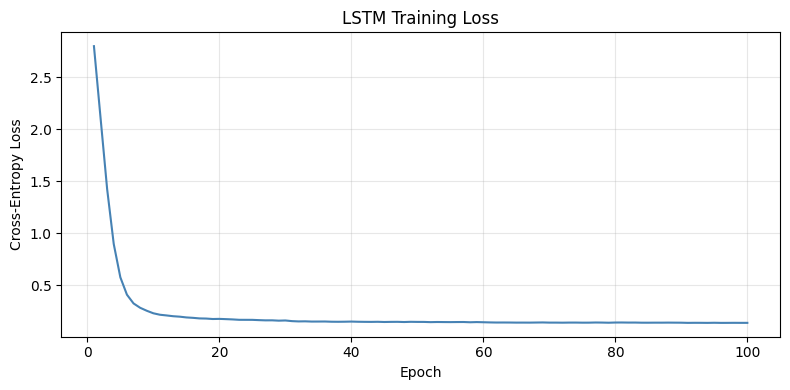

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history)+1), loss_history, color='steelblue')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# Component II – Transformer Based Sequential Data Generation

### Tasks
1. Same dataset as Component I
2. Apply **word-level** tokenization
3. Implement positional encoding for sequence order
4. Design Transformer encoder architecture
5. Train and generate sequences

### Task 2 – Word-Level Tokenization

In [9]:
# Build word vocabulary from corpus
all_words  = full_text.split()
vocab       = ['<PAD>', '<UNK>'] + sorted(set(all_words))
word2idx_w  = {w: i for i, w in enumerate(vocab)}
idx2word_w  = {i: w for w, i in word2idx_w.items()}
vocab_size_w = len(vocab)

print(f'Word vocabulary size: {vocab_size_w}')
print(f'Vocabulary          : {vocab}')

# Encode full text at word level
encoded_words = [word2idx_w.get(w, word2idx_w['<UNK>']) for w in all_words]
print(f'\nEncoded (first 10 words): {encoded_words[:10]}')

Word vocabulary size: 79
Vocabulary          : ['<PAD>', '<UNK>', 'a', 'accuracy', 'algorithms', 'and', 'are', 'artificial', 'assistants', 'automatically', 'automation', 'benefit', 'brain', 'by', 'chatbots', 'computers', 'create', 'data', 'decision', 'deep', 'dependencies', 'education', 'efficiency', 'for', 'from', 'generation', 'generative', 'handle', 'helps', 'human', 'improve', 'improves', 'in', 'information', 'intelligence', 'intelligent', 'is', 'language', 'learn', 'learned', 'learning', 'long', 'lstm', 'machine', 'making', 'model', 'models', 'modern', 'networks', 'neural', 'new', 'next', 'online', 'optimization', 'patterns', 'platforms', 'predict', 'prediction', 'process', 'productivity', 'recurrent', 'samples', 'sentence', 'sequence', 'simulate', 'step', 'structures', 'students', 'systems', 'technology', 'term', 'the', 'training', 'transforming', 'tutoring', 'use', 'used', 'useful', 'word']

Encoded (first 10 words): [7, 34, 68, 38, 54, 24, 17, 63, 46, 58]


In [10]:
SEQ_LEN_W = 8  # word-level sequence length

class WordDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data    = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx : idx + self.seq_len],         dtype=torch.long)
        y = torch.tensor(self.data[idx + 1 : idx + self.seq_len + 1], dtype=torch.long)
        return x, y

word_dataset    = WordDataset(encoded_words, SEQ_LEN_W)
word_dataloader = DataLoader(word_dataset, batch_size=16, shuffle=True)

print(f'Total word samples: {len(word_dataset)}')
print(f'Batches/epoch     : {len(word_dataloader)}')

Total word samples: 96
Batches/epoch     : 6


### Task 3 – Positional Encoding

In [11]:
class PositionalEncoding(nn.Module):
    """
    Standard sinusoidal positional encoding (Vaswani et al., 2017).
    Adds position information to token embeddings.
    """
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)            # (L, D)
        pos = torch.arange(0, max_len).unsqueeze(1)   # (L, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)            # even dims
        pe[:, 1::2] = torch.cos(pos * div)            # odd dims
        pe = pe.unsqueeze(0)                           # (1, L, D)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (B, T, D)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

print('PositionalEncoding module defined.')

PositionalEncoding module defined.


### Task 4 – Transformer Encoder Architecture

In [12]:
class TransformerLM(nn.Module):
    """
    Decoder-style Transformer language model using a causal mask
    so each position can only attend to previous positions.
    """
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2,
                 dim_ff=256, dropout=0.2, max_len=512):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc    = PositionalEncoding(d_model, max_len, dropout)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out      = nn.Linear(d_model, vocab_size)

    def _causal_mask(self, seq_len, device):
        """Upper-triangular mask to prevent attending to future tokens."""
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1).bool()
        return mask  # True = ignore

    def forward(self, x):
        # x: (B, T)
        emb  = self.pos_enc(self.embedding(x))                # (B, T, D)
        mask = self._causal_mask(x.size(1), x.device)         # (T, T)
        out  = self.transformer(emb, mask=mask)                # (B, T, D)
        return self.fc_out(out)                                # (B, T, V)


transformer_model = TransformerLM(vocab_size_w).to(device)
print(transformer_model)
total_params_t = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params_t:,}')

TransformerLM(
  (embedding): Embedding(79, 64, padding_idx=0)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=64, out_features=79, bias=True)
)

Trainable parameters: 110,159


### Task 5 – Train the Transformer Model

In [13]:
EPOCHS_T    = 150
LR_T        = 0.001
criterion_t = nn.CrossEntropyLoss(ignore_index=0)  # ignore PAD
optimizer_t = optim.Adam(transformer_model.parameters(), lr=LR_T)
scheduler_t = optim.lr_scheduler.CosineAnnealingLR(optimizer_t, T_max=EPOCHS_T)

transformer_model.train()
loss_history_t = []

for epoch in range(1, EPOCHS_T + 1):
    epoch_loss = 0.0
    for xb, yb in word_dataloader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_t.zero_grad()
        logits = transformer_model(xb)           # (B, T, V)
        loss   = criterion_t(logits.view(-1, vocab_size_w), yb.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(transformer_model.parameters(), max_norm=1.0)
        optimizer_t.step()
        epoch_loss += loss.item()

    scheduler_t.step()
    avg = epoch_loss / len(word_dataloader)
    loss_history_t.append(avg)

    if epoch % 15 == 0:
        print(f'Epoch [{epoch:3d}/{EPOCHS_T}]  Loss: {avg:.4f}')

print('\nTransformer training complete!')

Epoch [ 15/150]  Loss: 1.0572
Epoch [ 30/150]  Loss: 0.3601
Epoch [ 45/150]  Loss: 0.2037
Epoch [ 60/150]  Loss: 0.1503
Epoch [ 75/150]  Loss: 0.1234
Epoch [ 90/150]  Loss: 0.1213
Epoch [105/150]  Loss: 0.1138
Epoch [120/150]  Loss: 0.1052
Epoch [135/150]  Loss: 0.1006
Epoch [150/150]  Loss: 0.1008

Transformer training complete!


### Generate New Sequences (Transformer)

In [14]:
def generate_text_transformer(model, seed_words, num_words=20, temperature=0.9):
    """
    Generate `num_words` new words from a seed word list.
    """
    model.eval()
    tokens = [word2idx_w.get(w, word2idx_w['<UNK>']) for w in seed_words]

    with torch.no_grad():
        for _ in range(num_words):
            inp    = torch.tensor([tokens[-SEQ_LEN_W:]], dtype=torch.long).to(device)
            logits = model(inp)                                 # (1, T, V)
            probs  = torch.softmax(logits[0, -1] / temperature, dim=-1)
            next_id = torch.multinomial(probs, 1).item()
            # Skip PAD and UNK
            if next_id in (0, 1):
                next_id = torch.multinomial(probs, 5).tolist()
                next_id = next((i for i in next_id if i > 1), next_id[0])
            tokens.append(next_id)

    return ' '.join(idx2word_w[t] for t in tokens)


# --- Expected Output ---
seeds_w = [
    ["deep", "learning", "models"],
    ["sequence", "generation", "is"],
    ["neural", "networks", "simulate"],
]

print('='*60)
print('COMPONENT II – TRANSFORMER GENERATED TEXT')
print('='*60)
for seed in seeds_w:
    result = generate_text_transformer(transformer_model, seed, num_words=15, temperature=0.8)
    print(f'\nSeed : "{" ".join(seed)}"')
    print(f'Output: {result}')
    print('-'*60)

COMPONENT II – TRANSFORMER GENERATED TEXT

Seed : "deep learning models"
Output: deep learning models improve sequence learning generative models create new samples from learned patterns language models predict the
------------------------------------------------------------

Seed : "sequence generation is"
Output: sequence generation is used in chatbots and assistants machine learning helps computers learn automatically training data improves model
------------------------------------------------------------

Seed : "neural networks simulate"
Output: neural networks simulate human brain structures optimization algorithms improve learning efficiency technology is transforming modern education online learning
------------------------------------------------------------


### Training Loss (Transformer)

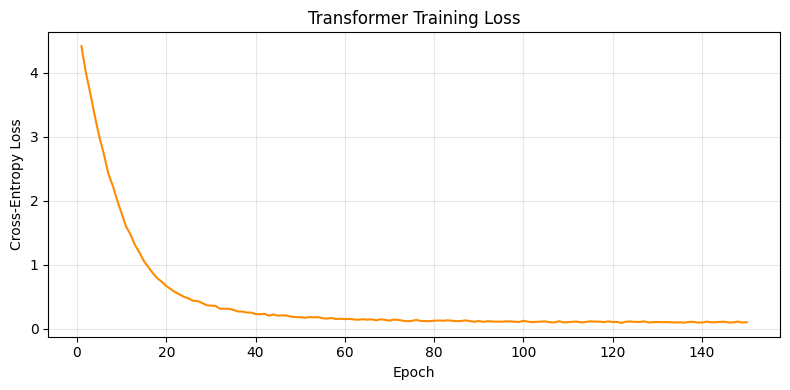

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history_t)+1), loss_history_t, color='darkorange')
plt.title('Transformer Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Comparison: LSTM vs Transformer

Model                    Params  Tokenization   
------------------------------------------------------------
LSTM                    236,442  Character      
Transformer             110,159  Word           


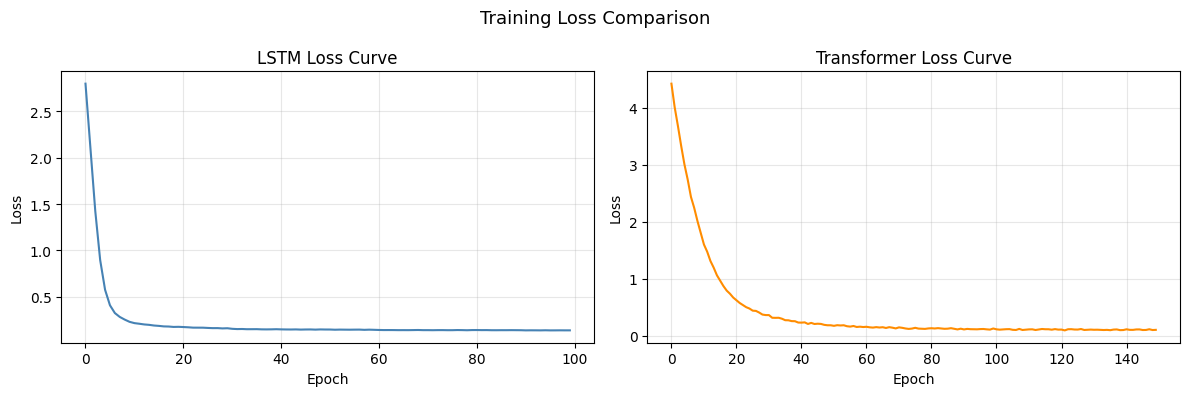

In [16]:
print('='*60)
print(f'{'Model':<20} {'Params':>10}  {'Tokenization':<15}')
print('-'*60)
print(f'{'LSTM':<20} {total_params:>10,}  {'Character':<15}')
print(f'{'Transformer':<20} {total_params_t:>10,}  {'Word':<15}')
print('='*60)

# Side-by-side loss comparison
epochs_common = min(len(loss_history), len(loss_history_t))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_history,   color='steelblue',  label='LSTM (char)')
ax1.set_title('LSTM Loss Curve')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(loss_history_t, color='darkorange', label='Transformer (word)')
ax2.set_title('Transformer Loss Curve')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.grid(alpha=0.3)

plt.suptitle('Training Loss Comparison', fontsize=13)
plt.tight_layout()
plt.show()